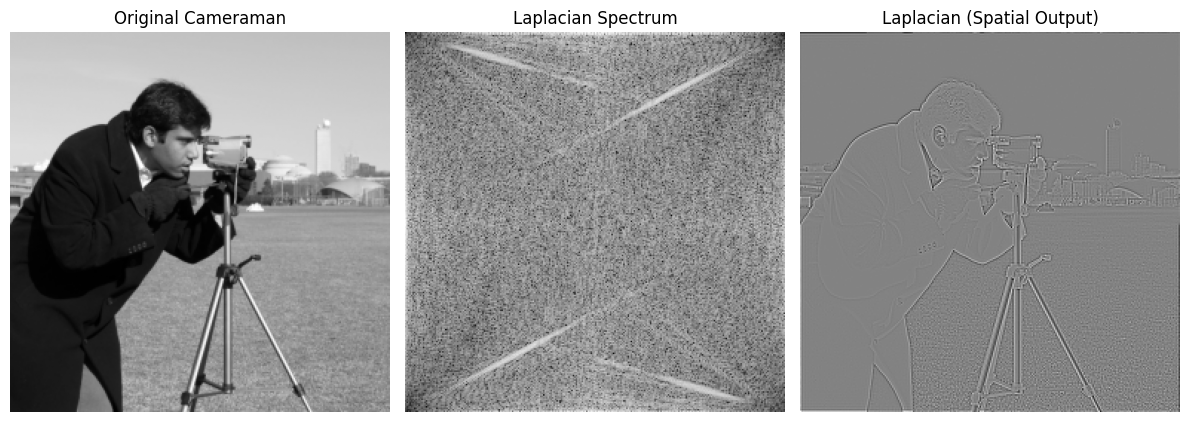

In [4]:
# --- Code from the lab manual ---
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256))   # Resize for faster FFT (optional)

# Get image size
M, N = image.shape

# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)   # column vector of frequencies for rows
v = np.fft.fftfreq(N).reshape(1, -1)   # row vector of frequencies for columns

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT
F = np.fft.fft2(image)

# Apply Laplacian filter in frequency domain (pointwise multiplication)
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)'); plt.axis('off')

plt.tight_layout(); plt.show()

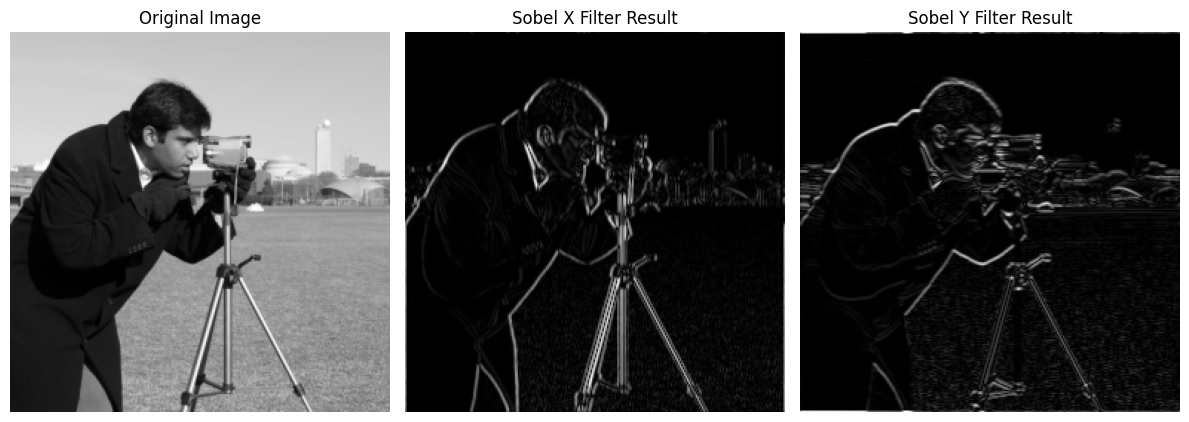

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from scipy.fft import fft2, ifft2, ifftshift

# Load and resize the image
image = data.camera()
image = resize(image, (256, 256))  # Resize for faster processing

# Define Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0, 0, 0],
                    [ 1, 2, 1]])

# Function to center and embed the kernel in the image shape
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return fft2(ifftshift(padded))  # Shift the kernel before applying FFT

# Compute the FFT of the image
F = fft2(image)

# Embed Sobel filters in the frequency domain
sobel_x_freq = center_embed_kernel(sobel_x, image.shape)
sobel_y_freq = center_embed_kernel(sobel_y, image.shape)

# Multiply in the frequency domain
F_sobel_x = F * sobel_x_freq
F_sobel_y = F * sobel_y_freq

# Apply inverse FFT to get the spatial domain result
sobel_x_image = np.abs(ifft2(F_sobel_x))
sobel_y_image = np.abs(ifft2(F_sobel_y))

# Plot the results
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sobel_x_image, cmap='gray')
plt.title('Sobel X Filter Result')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sobel_y_image, cmap='gray')
plt.title('Sobel Y Filter Result')
plt.axis('off')

plt.tight_layout()
plt.show()